In [2]:
# =============================================================
# CELL 1: Imports and paths
# =============================================================
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = Path("/Users/yashaswiaryan/Projects/WOLF")
PRICE_DIR = BASE_DIR / "full_history"
NEWS_FILE = BASE_DIR / "All_external.csv"

In [3]:
# =============================================================
# CELL 2: Profile the news file (size + quick peek without full load)
# =============================================================

# Check file size first
news_size_gb = NEWS_FILE.stat().st_size / (1024**3)
print(f"All_external.csv size: {news_size_gb:.2f} GB")

# Count total rows (fast — just counts lines)
print("Counting rows... (this may take a minute)")
with open(NEWS_FILE, 'r', errors='ignore') as f:
    total_news_rows = sum(1 for _ in f) - 1  # subtract header
print(f"Total news records: {total_news_rows:,}")

# Load just the first 1000 rows to inspect
news_sample = pd.read_csv(NEWS_FILE, nrows=1000)
print(f"\nColumns: {list(news_sample.columns)}")
print(f"\nNull % in sample:")
print(news_sample.isnull().mean().round(3) * 100)
print(f"\nSample date range: {news_sample['Date'].min()} to {news_sample['Date'].max()}")
print(f"\nUnique tickers in sample: {news_sample['Stock_symbol'].nunique()}")
print(f"Publishers in sample: {news_sample['Publisher'].unique()[:10]}")

All_external.csv size: 5.34 GB
Counting rows... (this may take a minute)
Total news records: 30,114,915

Columns: ['Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']

Null % in sample:
Date                  0.0
Article_title         0.0
Stock_symbol          0.0
Url                   0.0
Publisher             0.0
Author              100.0
Article             100.0
Lsa_summary         100.0
Luhn_summary        100.0
Textrank_summary    100.0
Lexrank_summary     100.0
dtype: float64

Sample date range: 2009-08-16 00:00:00 UTC to 2020-06-05 06:30:54 UTC

Unique tickers in sample: 1
Publishers in sample: ['Benzinga Insights' 'Lisa Levin' 'Vick Meyer' 'vishwanath@benzinga.com'
 'Benzinga Newsdesk' 'Tyree Gorges' 'Luke J Jacobi' 'Wayne Duggan'
 'Shivdeep Dhaliwal' 'luke@benzinga.com']


In [4]:
# =============================================================
# CELL 3: Profile stock price files
# =============================================================

price_files = sorted(PRICE_DIR.glob("*.csv"))
print(f"Total stock price files: {len(price_files)}")

# Read one sample to get column names
sample_price = pd.read_csv(price_files[0], nrows=5)
print(f"\nSample file: {price_files[0].name}")
print(f"Columns: {list(sample_price.columns)}")
print(f"Dtypes:\n{sample_price.dtypes}")
print(f"\n{sample_price.head()}")

Total stock price files: 7693

Sample file: A.csv
Columns: ['date', 'volume', 'open', 'high', 'low', 'close', 'adj close']
Dtypes:
date          object
volume         int64
open         float64
high         float64
low          float64
close        float64
adj close    float64
dtype: object

         date   volume        open        high         low       close  \
0  2023-12-28   892600  140.539993  140.809998  139.649994  139.770004   
1  2023-12-27  1182300  139.779999  140.160004  139.080002  139.820007   
2  2023-12-26   948400  139.309998  140.470001  139.089996  139.809998   
3  2023-12-22  1204100  139.610001  140.360001  138.789993  139.570007   
4  2023-12-21  1685700  139.380005  139.669998  138.000000  138.940002   

    adj close  
0  139.770004  
1  139.820007  
2  139.809998  
3  139.570007  
4  138.940002  


In [5]:
#=============================================================
# CELL 4: Scan all price files for coverage stats
# =============================================================

print("Scanning all price files... (may take 1-2 minutes)")
ticker_stats = []
for f in price_files:
    ticker = f.stem
    try:
        df = pd.read_csv(f)
        date_col = df.columns[0]  # first column is likely Date
        ticker_stats.append({
            "ticker": ticker,
            "rows": len(df),
            "start": df[date_col].min(),
            "end": df[date_col].max(),
            "size_kb": f.stat().st_size / 1024,
            "null_pct": df.isnull().mean().mean() * 100
        })
    except Exception as e:
        print(f"  Error: {ticker} — {e}")

stats_df = pd.DataFrame(ticker_stats)
print(f"\nTotal tickers: {len(stats_df)}")
print(f"\nRow count stats:")
print(stats_df["rows"].describe().round(0))

Scanning all price files... (may take 1-2 minutes)

Total tickers: 7693

Row count stats:
count     7693.0
mean      3858.0
std       3208.0
min          1.0
25%       1384.0
50%       2939.0
75%       5690.0
max      15606.0
Name: rows, dtype: float64


In [6]:
# =============================================================
# CELL 5: Load news ticker counts (chunked — memory safe)
# =============================================================

# Read only the Stock_symbol column to count articles per ticker
print("Counting articles per ticker... (chunked read)")
ticker_article_counts = {}
for chunk in pd.read_csv(NEWS_FILE, usecols=["Stock_symbol"], chunksize=500_000):
    counts = chunk["Stock_symbol"].value_counts()
    for ticker, count in counts.items():
        ticker_article_counts[ticker] = ticker_article_counts.get(ticker, 0) + count

news_ticker_df = pd.DataFrame(
    sorted(ticker_article_counts.items(), key=lambda x: -x[1]),
    columns=["ticker", "article_count"]
)
print(f"\nTickers with news data: {len(news_ticker_df)}")
print(f"\nTop 20 tickers by news volume:")
print(news_ticker_df.head(20).to_string(index=False))

Counting articles per ticker... (chunked read)


/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_64301/1396529985.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(NEWS_FILE, usecols=["Stock_symbol"], chunksize=500_000):
/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_64301/1396529985.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(NEWS_FILE, usecols=["Stock_symbol"], chunksize=500_000):
/var/folders/cd/cmftsq815jv_1rl8njn3b4dw0000gn/T/ipykernel_64301/1396529985.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(NEWS_FILE, usecols=["Stock_symbol"], chunksize=500_000):



Tickers with news data: 6619

Top 20 tickers by news volume:
ticker  article_count
    KR           5127
  GILD           4974
  DISH           4624
   EWJ           4526
   MDT           4476
    HD           4453
   MYL           4446
   JWN           4432
   FDX           4399
  FCAU           4334
   FCX           4296
   WDC           4219
  GRPN           4192
  AVGO           4149
   VMW           4104
   TWX           4099
   SLV           4012
   CSX           4007
   BLK           3989
    EA           3938


In [7]:
# =============================================================
# CELL 6: Find best tickers — those with BOTH good price + news data
# =============================================================

price_tickers = set(stats_df["ticker"])
news_tickers = set(news_ticker_df["ticker"])
overlap = price_tickers & news_tickers

print(f"\nTickers with price data: {len(price_tickers)}")
print(f"Tickers with news data: {len(news_tickers)}")
print(f"Tickers with BOTH: {len(overlap)}")

# Merge to find the best candidates
merged = stats_df[stats_df["ticker"].isin(overlap)].merge(
    news_ticker_df, on="ticker"
)
merged["score"] = merged["rows"] * 0.3 + merged["article_count"] * 0.7  # weight news more

# Top candidates for our project
top_candidates = merged.nlargest(30, "score")[["ticker", "rows", "article_count", "start", "end"]]
print(f"\n🏆 TOP 30 CANDIDATE TICKERS (best price + news coverage):")
print(top_candidates.to_string(index=False))



Tickers with price data: 7693
Tickers with news data: 6619
Tickers with BOTH: 4031

🏆 TOP 30 CANDIDATE TICKERS (best price + news coverage):
ticker  rows  article_count      start        end
    KR 10907           5127 1977-01-03 2020-04-01
    AA 15605           2953 1962-01-02 2023-12-28
   JNJ 15605           2928 1962-01-02 2023-12-28
   MDT 11899           4476 1973-05-02 2020-07-02
    KO 15606           2874 1962-01-02 2023-12-28
   TXN 13006           3872 1972-06-01 2023-12-28
   AXP 13006           3783 1972-06-01 2023-12-28
   FDX 11528           4399 1978-04-12 2023-12-28
    FL 15605           2621 1962-01-02 2023-12-28
   HAL 13007           3641 1972-06-01 2023-12-28
   MRK 13618           3335 1970-01-02 2023-12-28
   JWN 11040           4432 1980-03-17 2023-12-28
   LLY 13006           3538 1972-06-01 2023-12-28
   WDC 11387           4219 1978-10-31 2023-12-28
    ED 15605           2244 1962-01-02 2023-12-28
   PCG 13006           3340 1972-06-01 2023-12-28
   MYL 1

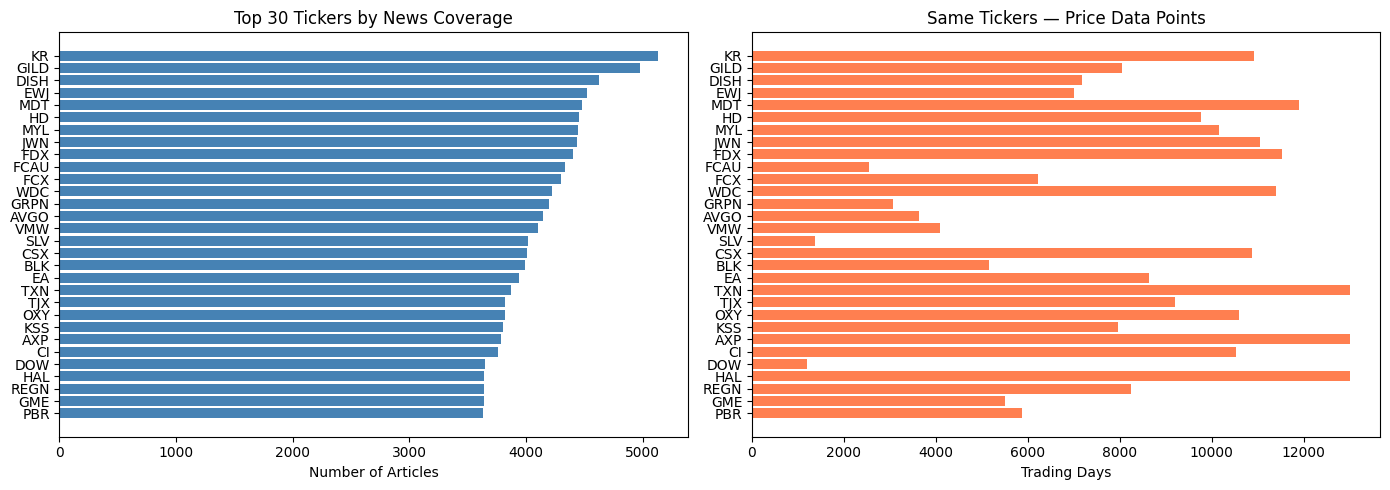

In [10]:
# =============================================================
# CELL 7: Quick visualization
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# News volume distribution (top 30)
top30 = merged.nlargest(30, "article_count")
axes[0].barh(top30["ticker"], top30["article_count"], color="steelblue")
axes[0].set_xlabel("Number of Articles")
axes[0].set_title("Top 30 Tickers by News Coverage")
axes[0].invert_yaxis()

# Price data rows (top 30 same tickers)
axes[1].barh(top30["ticker"], top30["rows"], color="coral")
axes[1].set_xlabel("Trading Days")
axes[1].set_title("Same Tickers — Price Data Points")
axes[1].invert_yaxis()

plt.tight_layout()
# plt.savefig("../reports/ticker_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

# print("\n✅ Chart saved to reports/ticker_coverage.png")
